In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


Zadanie 1. Implementacja PCA z wykorzystaniem Scikit-Learn (zestaw danych z zadania
wprowadzającego).
1.1. Wstępne przetworzenie danych oraz standaryzacja.
1.2. Redukcja wymiarowości do dwóch wymiarów.
1.3. Dopasowanie transformatora i uzyskanie składowych głównych:
o Dopasowanie transformatora PCA do danych – przekształcenie oryginalnych danych
na dwie główne składowe, rzutując je na wektory własne odpowiadające dwóm
największym wartościom własnym.

In [18]:
df = pd.read_csv("data.csv").dropna(axis=1, how="all")
df['target'] = df['diagnosis'].apply(lambda x: 1 if x == 'M' else 0)
df.head()
#print(df.isnull().sum())

features = df.drop(columns=['id', 'diagnosis', 'target'])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [19]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['target'] = df['target']

pca_df.head()

,PC1,PC2,target
0,9.192837,1.948583,1
1,2.387802,-3.768172,1
2,5.733896,-1.075174,1
3,7.122953,10.275589,1
4,3.935302,-1.948072,1


In [20]:
explained_variance = pca.explained_variance_ratio_

1.4. Wizualizacja głównych składowych:
o Wykres punktowy z kolumną 'Target': dodaj kolory lub znaczniki według wartości
kolumny „Target”, aby sprawdzić, jak dobrze składowe główne rozróżniają klasy.

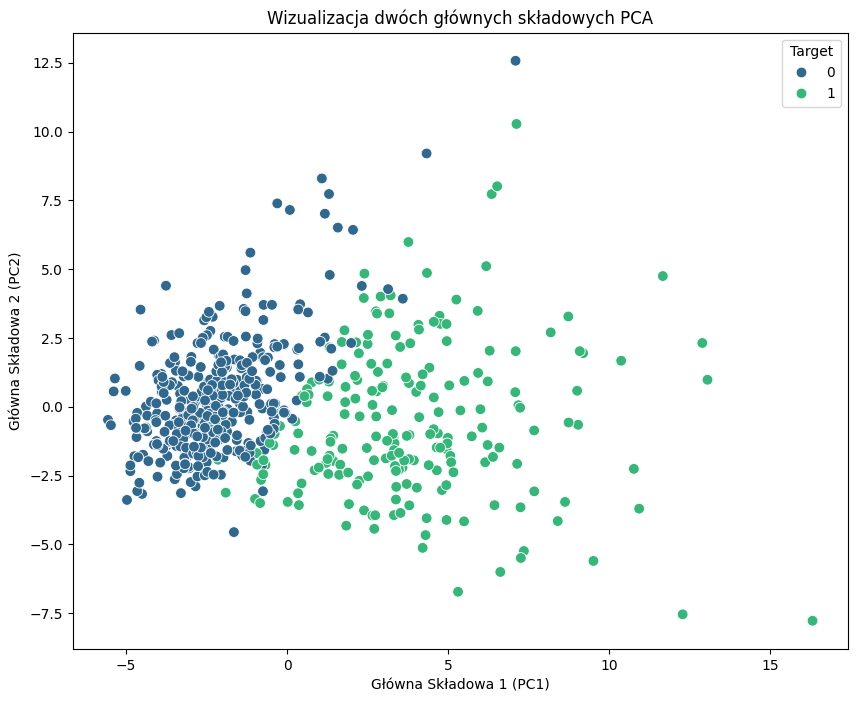

In [21]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='target', palette='viridis', s=60)
plt.title("Wizualizacja dwóch głównych składowych PCA")
plt.xlabel("Główna Składowa 1 (PC1)")
plt.ylabel("Główna Składowa 2 (PC2)")
plt.legend(title="Target")
plt.show()


1.5. Wyświetlenie składowych i zależności:
1.5.1. Atrybut components_ – po dopasowaniu transformatora należy wyświetlić atrybut
components_, aby zobaczyć macierz składowych głównych. Składowe te
reprezentują wektory własne, które określają kierunki maksymalnej zmienności
danych.
1.5.2. Mapa cieplna – należy wykorzystać mapę cieplną do przedstawienia relacji między
składowymi głównymi a oryginalnymi zmiennymi. Każda zmienna wejściowa (z
30-wymiarowego zbioru danych) jest reprezentowana w odniesieniu do głównych
składowych.

In [22]:
print("Macierz składowych głównych (components_):\n", pca.components_)

Macierz składowych głównych (components_):
 [[ 0.21890244  0.10372458  0.22753729  0.22099499  0.14258969  0.23928535
   0.25840048  0.26085376  0.13816696  0.06436335  0.20597878  0.01742803
   0.21132592  0.20286964  0.01453145  0.17039345  0.15358979  0.1834174
   0.04249842  0.10256832  0.22799663  0.10446933  0.23663968  0.22487053
   0.12795256  0.21009588  0.22876753  0.25088597  0.12290456  0.13178394]
 [-0.23385713 -0.05970609 -0.21518136 -0.23107671  0.18611302  0.15189161
   0.06016536 -0.0347675   0.19034877  0.36657547 -0.10555215  0.08997968
  -0.08945723 -0.15229263  0.20443045  0.2327159   0.19720728  0.13032156
   0.183848    0.28009203 -0.21986638 -0.0454673  -0.19987843 -0.21935186
   0.17230435  0.14359317  0.09796411 -0.00825724  0.14188335  0.27533947]]


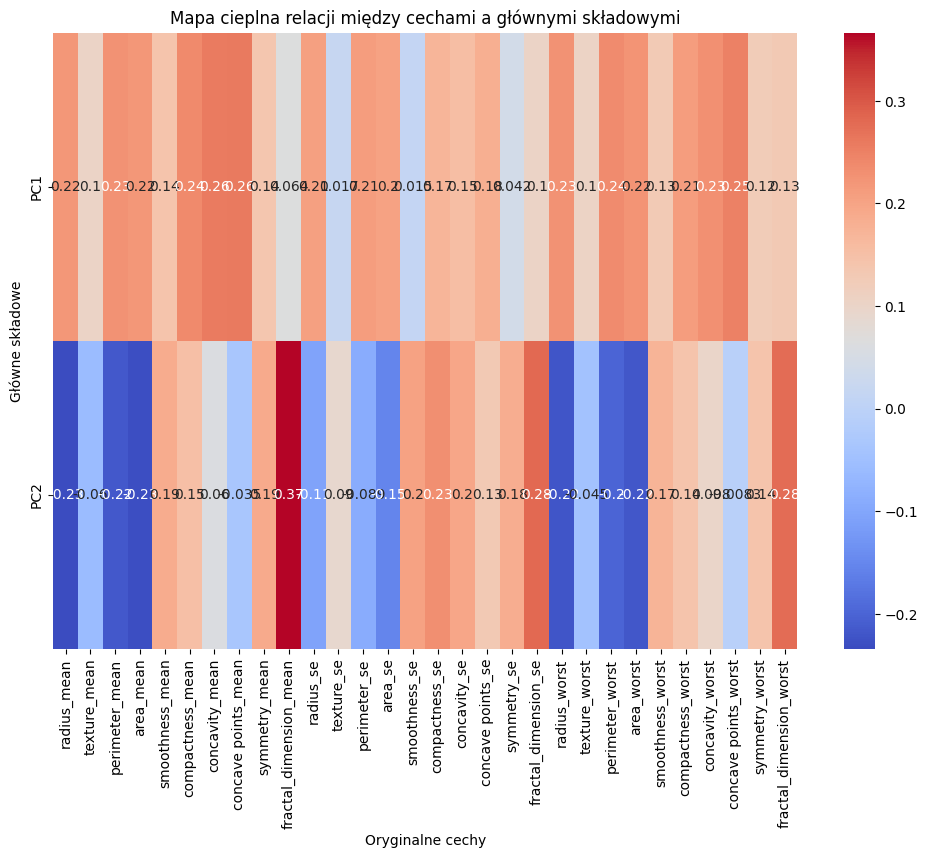

In [23]:
plt.figure(figsize=(12, 8))
sns.heatmap(pca.components_, cmap='coolwarm', annot=True, xticklabels=features.columns, yticklabels=['PC1', 'PC2'])
plt.title("Mapa cieplna relacji między cechami a głównymi składowymi")
plt.xlabel("Oryginalne cechy")
plt.ylabel("Główne składowe")
plt.show()


1.6. Analiza wariancji:
1.6.1. Wariancja składowych - jaki procent wariancji wyjaśniają poszczególne składowe
(PC1 i PC2).
1.6.2. Wariancja całkowita – jaki procent całkowitej wariancji danych jest wyjaśniany
przez dwie wybrane składowe.
1.6.3. Liczba składowych dla 95% i 99% wariancji – obliczenie liczby składowych, które
pozwalają wyjaśnić ponad 905% i 99% całkowitej wariancji.
1.6.4. Wykres wariancji od liczby składowych – zobrazowanie zależności między liczbą
składowych a wariancją, aby lepiej zrozumieć, jak szybko maleje wkład kolejnych
składowych w całkowitą wariancję danych.

In [24]:
explained_variance = pca.explained_variance_ratio_
print(f"Wariancja wyjaśniana przez PC1: {explained_variance[0]:.2%}")
print(f"Wariancja wyjaśniana przez PC2: {explained_variance[1]:.2%}")

Wariancja wyjaśniana przez PC1: 44.27%
Wariancja wyjaśniana przez PC2: 18.97%


In [25]:
total_variance = np.sum(explained_variance)
print(f"Łączna wariancja wyjaśniana przez PC1 i PC2: {total_variance:.2%}")

Łączna wariancja wyjaśniana przez PC1 i PC2: 63.24%


In [26]:
# PCA na pełnym zestawie cech
pca_full = PCA().fit(scaled_features)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

num_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
num_components_99 = np.argmax(cumulative_variance >= 0.99) + 1
print(f"Liczba składowych dla 95% wariancji: {num_components_95}")
print(f"Liczba składowych dla 99% wariancji: {num_components_99}")

Liczba składowych dla 95% wariancji: 10
Liczba składowych dla 99% wariancji: 17


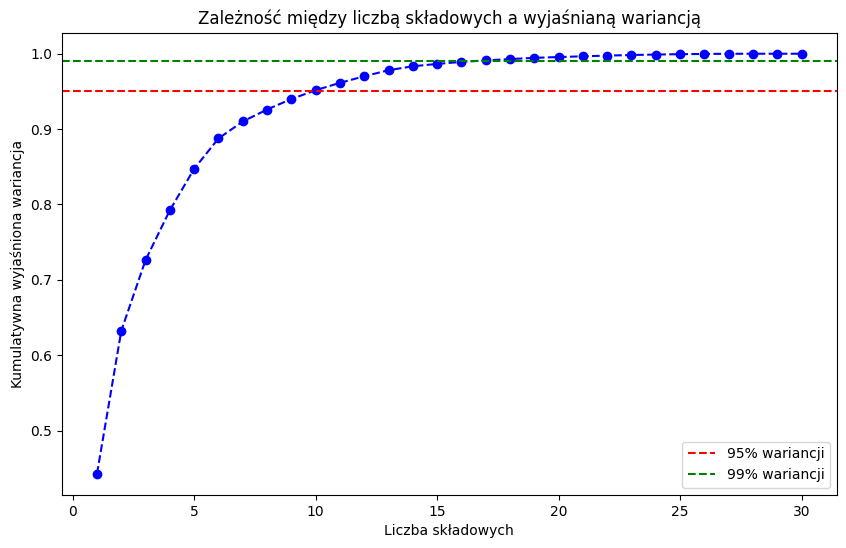

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.xlabel("Liczba składowych")
plt.ylabel("Kumulatywna wyjaśniona wariancja")
plt.title("Zależność między liczbą składowych a wyjaśnianą wariancją")
plt.axhline(y=0.95, color='r', linestyle='--', label="95% wariancji")
plt.axhline(y=0.99, color='g', linestyle='--', label="99% wariancji")
plt.legend()
plt.show()


1.7. Przeprowadzenie PCA na danych oryginalnych (pomijając standaryzację w kroku 2.1)
i należy wykonać pozostałe kroki (od 2.2 do końca) na oryginalnych danych, aby
porównać wpływ standaryzacji na wyniki PCA.

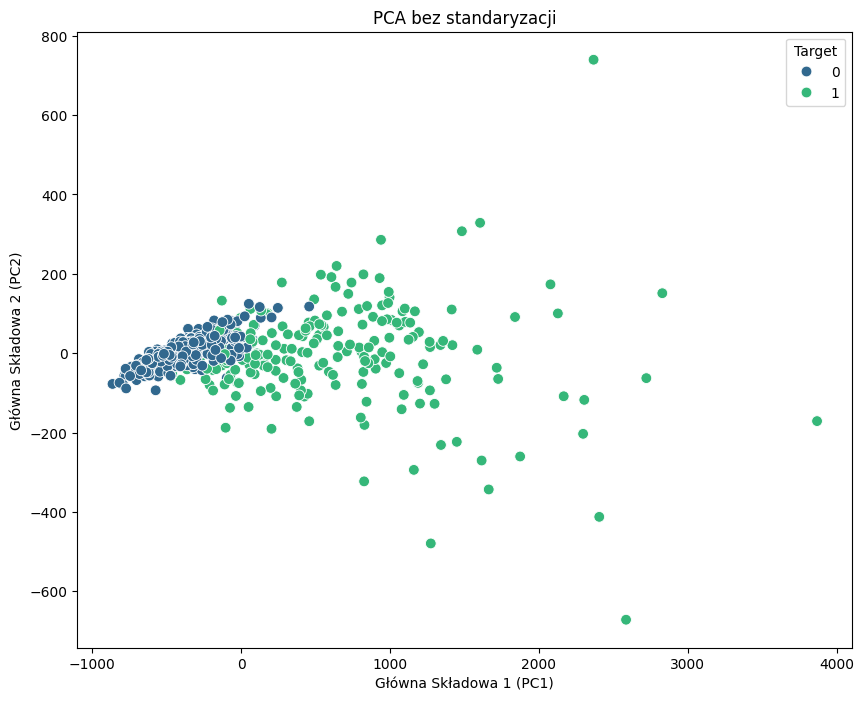

In [28]:
# PCA na niestandaryzowanych danych
pca_no_scaling = PCA(n_components=2)
principal_components_no_scaling = pca_no_scaling.fit_transform(features)
pca_df_no_scaling = pd.DataFrame(data=principal_components_no_scaling, columns=['PC1', 'PC2'])
pca_df_no_scaling['target'] = df['target']

# Wizualizacja
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df_no_scaling, x='PC1', y='PC2', hue='target', palette='viridis', s=60)
plt.title("PCA bez standaryzacji")
plt.xlabel("Główna Składowa 1 (PC1)")
plt.ylabel("Główna Składowa 2 (PC2)")
plt.legend(title="Target")
plt.show()
